# GAWD Language Usage

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pavt/GHAW-H/blob/main/notebooks/language_usage.ipynb)

Language usage summary for **A Dataset of GitHub Agentic Workflow Histories: Early Adopters**.

This follows the compact structure of the AIDev `language_usage.ipynb`: load repository and event data, compute language counts/percentages, and produce language-focused figures.


In [1]:
from __future__ import annotations

import importlib.util
import subprocess
import sys
from io import BytesIO
from pathlib import Path
from urllib.request import urlopen

REQUIRED_PACKAGES = {
    "pandas": "pandas",
    "pyarrow": "pyarrow",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}

if "google.colab" in sys.modules:
    missing = [
        package
        for package, import_name in REQUIRED_PACKAGES.items()
        if importlib.util.find_spec(import_name) is None
    ]
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

DATASET_ID = "pavtch/GHAW-H"
DATASET_REVISION = "main"
LOCAL_RELEASE_CANDIDATES = [
    Path(".."),
    Path("."),
    Path("../releases/gh-aw-early-adopters-source-history-2026-06-26"),
    Path("releases/gh-aw-early-adopters-source-history-2026-06-26"),
    Path("../releases/gawd"),
    Path("releases/gawd"),
]
LOCAL_RELEASE_MIRROR = next(
    (
        path.resolve()
        for path in LOCAL_RELEASE_CANDIDATES
        if (path / "data").is_dir() and any((path / "data").glob("*.parquet"))
    ),
    None,
)
USE_LOCAL_MIRROR = "google.colab" not in sys.modules and LOCAL_RELEASE_MIRROR is not None


def remote_parquet_url(table_name: str) -> str:
    return (
        f"https://huggingface.co/datasets/{DATASET_ID}/resolve/"
        f"{DATASET_REVISION}/data/{table_name}.parquet"
    )


def local_parquet_path(table_name: str) -> Path:
    if LOCAL_RELEASE_MIRROR is None:
        raise FileNotFoundError("No local release mirror with a data/ directory was found.")
    return LOCAL_RELEASE_MIRROR / "data" / f"{table_name}.parquet"


def parquet_path(table_name: str) -> str:
    if USE_LOCAL_MIRROR:
        return str(local_parquet_path(table_name))
    return remote_parquet_url(table_name)


def read_parquet_table(table_name: str) -> pd.DataFrame:
    if USE_LOCAL_MIRROR:
        return pd.read_parquet(local_parquet_path(table_name))

    try:
        with urlopen(remote_parquet_url(table_name)) as response:
            return pd.read_parquet(BytesIO(response.read()))
    except Exception:
        if LOCAL_RELEASE_MIRROR is not None:
            return pd.read_parquet(local_parquet_path(table_name))
        raise

mpl.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "axes.linewidth": 1.0,
        "axes.labelsize": 14,
        "axes.titlesize": 15,
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 11,
        "legend.title_fontsize": 11,
        "figure.dpi": 160,
    }
)
sns.set_style("whitegrid")

NOTEBOOK_DIR = Path("data_analysis") if Path("data_analysis").is_dir() else Path(".")
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TOP_N = 10

import matplotlib.dates as mdates
repository_df = read_parquet_table("repository")
source_snapshot_df = read_parquet_table("source_markdown_file_snapshot")
source_version_df = read_parquet_table("source_markdown_file_version")

def save_and_show(fig: plt.Figure, out: Path) -> None:
    png_out = out.with_suffix(".png")
    pdf_out = out.with_suffix(".pdf")
    fig.savefig(png_out, bbox_inches="tight", dpi=300)
    fig.savefig(pdf_out, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(png_out)))
    print("Wrote", png_out)
    print("Wrote", pdf_out)


In [2]:
# %%
def build_adoption_table() -> pd.DataFrame:
    events = (
        source_version_df.merge(
            source_snapshot_df,
            on="source_markdown_file_snapshot_id",
            how="inner",
            validate="many_to_one",
        )
        .merge(repository_df, on="repository_id", how="left", validate="many_to_one")
    )
    events["committed_at"] = pd.to_datetime(events["committed_at"], utc=True, errors="coerce")
    events = events.dropna(subset=["committed_at"]).sort_values(
        ["repository_id", "committed_at", "rank"]
    )
    adoption = (
        events.groupby("repository_id", as_index=False)
        .agg(
            repo_full_name=("repo_full_name", "first"),
            main_language=("main_language", "first"),
            stars=("stars", "first"),
            forks=("forks", "first"),
            adoption_date=("committed_at", "first"),
            observed_versions=("source_markdown_file_version_id", "count"),
        )
        .sort_values("adoption_date")
    )
    adoption["language"] = adoption["main_language"].fillna("Unknown")
    adoption["adoption_month"] = (
        adoption["adoption_date"].dt.tz_convert(None).dt.to_period("M").dt.to_timestamp()
    )
    return adoption


def language_counts(adoption: pd.DataFrame) -> pd.DataFrame:
    counts = adoption["language"].value_counts(dropna=False).reset_index()
    counts.columns = ["language", "repositories"]
    counts["percentage"] = counts["repositories"] / counts["repositories"].sum() * 100
    return counts


def plot_total_language_percentages(counts: pd.DataFrame, top_n: int = TOP_N) -> None:
    plot_df = counts.head(top_n).copy()
    fig, ax = plt.subplots(figsize=(7, 0.45 * len(plot_df) + 1.4))
    sns.barplot(
        data=plot_df,
        y="language",
        x="percentage",
        orient="h",
        color="#1C3F60",
        ax=ax,
    )
    ax.set_xlabel("Percentage of Repositories (%)")
    ax.set_ylabel(None)
    ax.set_title("Top Languages Used by Observed GH-AW Adopters", weight="bold")
    ax.set_xlim(0, plot_df["percentage"].max() * 1.15)
    ax.grid(False)
    sns.despine(ax=ax)
    fig.tight_layout()
    out = FIG_DIR / "gawd_total_language_percentages_top.png"
    save_and_show(fig, out)


def plot_language_cumulative(adoption: pd.DataFrame, top_n: int = 8) -> None:
    top_languages = adoption["language"].value_counts().head(top_n).index
    plot_df = adoption.copy()
    plot_df["language_group"] = plot_df["language"].where(
        plot_df["language"].isin(top_languages), "Other"
    )
    monthly = (
        plot_df.groupby(["language_group", "adoption_month"], as_index=False)
        .agg(new_repositories=("repository_id", "count"))
        .sort_values(["language_group", "adoption_month"])
    )
    all_months = pd.date_range(
        adoption["adoption_month"].min(), adoption["adoption_month"].max(), freq="MS"
    )
    complete_index = pd.MultiIndex.from_product(
        [sorted(monthly["language_group"].unique()), all_months],
        names=["language_group", "adoption_month"],
    )
    monthly = (
        monthly.set_index(["language_group", "adoption_month"])
        .reindex(complete_index, fill_value=0)
        .reset_index()
    )
    monthly["cumulative_repositories"] = monthly.groupby("language_group")[
        "new_repositories"
    ].cumsum()

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.lineplot(
        data=monthly,
        x="adoption_month",
        y="cumulative_repositories",
        hue="language_group",
        marker="o",
        linewidth=2.2,
        palette="tab10",
        ax=ax,
    )
    ax.set_title("Cumulative Observed GH-AW Adoption by Main Language", weight="bold")
    ax.set_xlabel("First observed adoption month")
    ax.set_ylabel("Cumulative repositories")
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    ax.legend(title="Main language", bbox_to_anchor=(1.02, 1), loc="upper left")
    sns.despine(ax=ax)
    fig.tight_layout()
    out = FIG_DIR / "gawd_cumulative_language_usage.png"
    save_and_show(fig, out)


In [3]:
adoption_df = build_adoption_table()
count_df = language_counts(adoption_df)
count_df


,language,repositories,percentage
0,TypeScript,52,19.847328
1,Go,41,15.648855
2,C#,32,12.213740
3,Python,29,11.068702
4,Makefile,21,8.015267
5,F#,18,6.870229
6,Rust,13,4.961832
7,JavaScript,11,4.198473
8,Java,10,3.816794
9,C++,7,2.671756


Wrote data_analysis/figs/gawd_total_language_percentages_top.png
Wrote data_analysis/figs/gawd_total_language_percentages_top.pdf


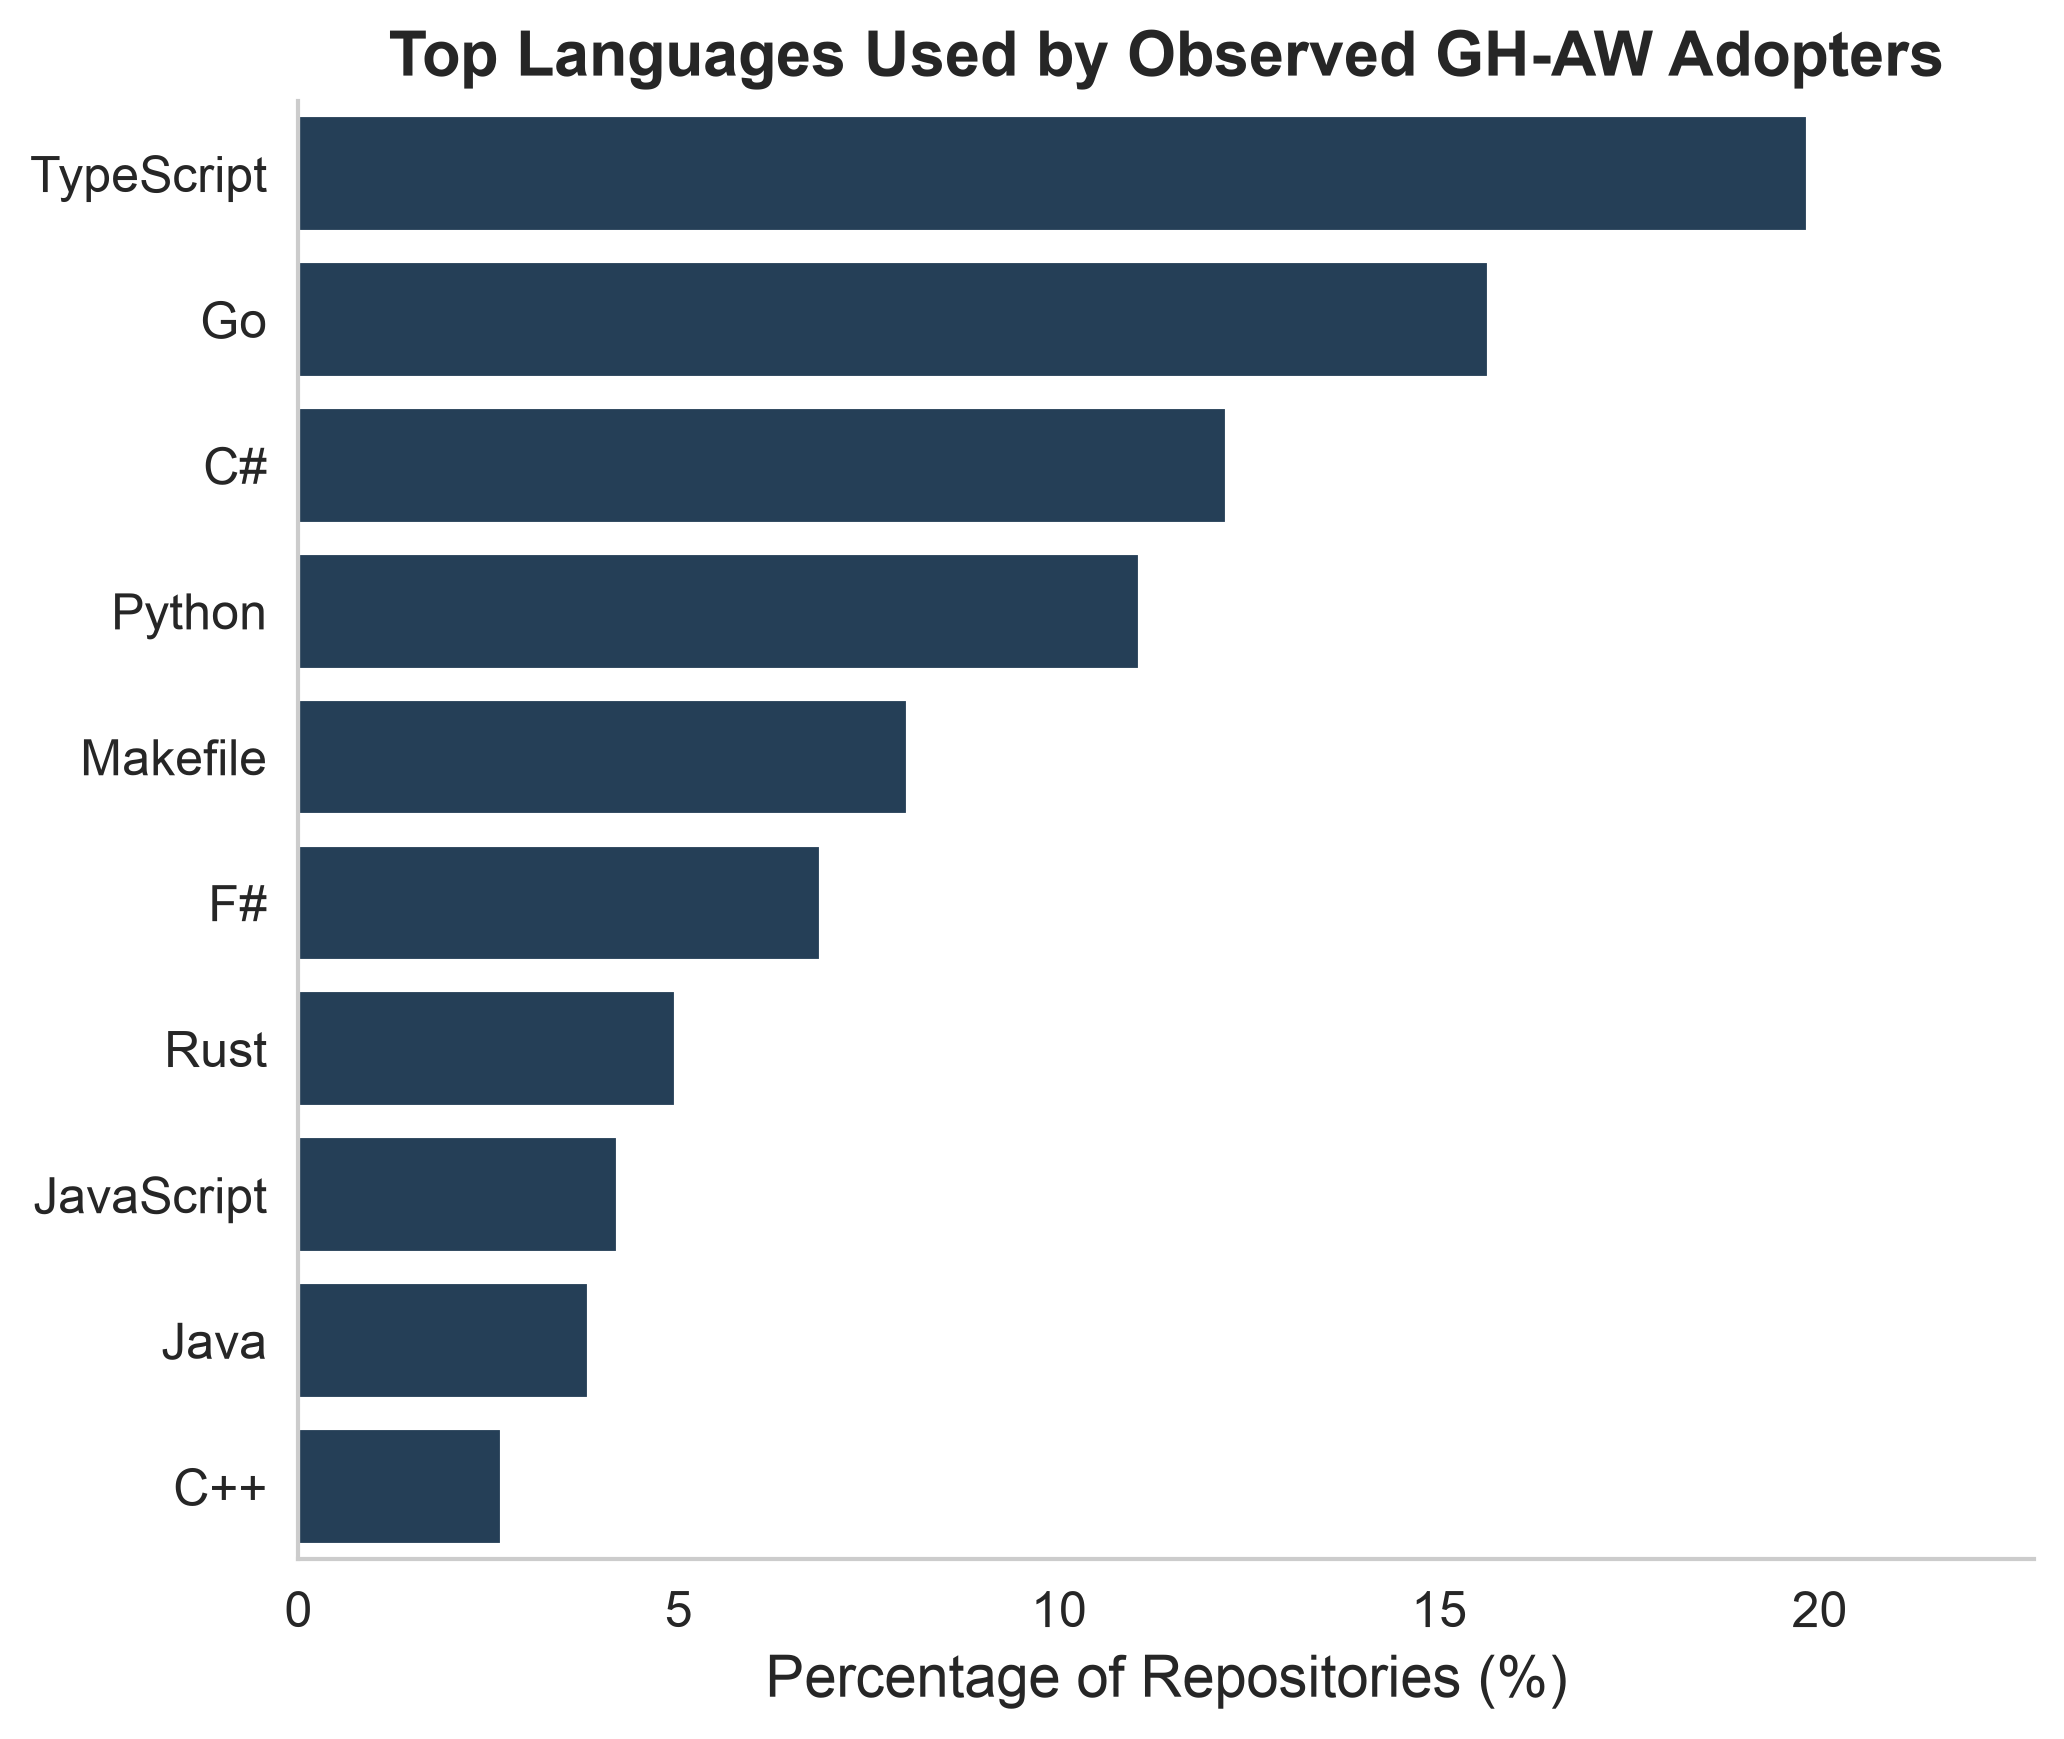

In [4]:
plot_total_language_percentages(count_df, top_n=TOP_N)


Wrote data_analysis/figs/gawd_cumulative_language_usage.png
Wrote data_analysis/figs/gawd_cumulative_language_usage.pdf


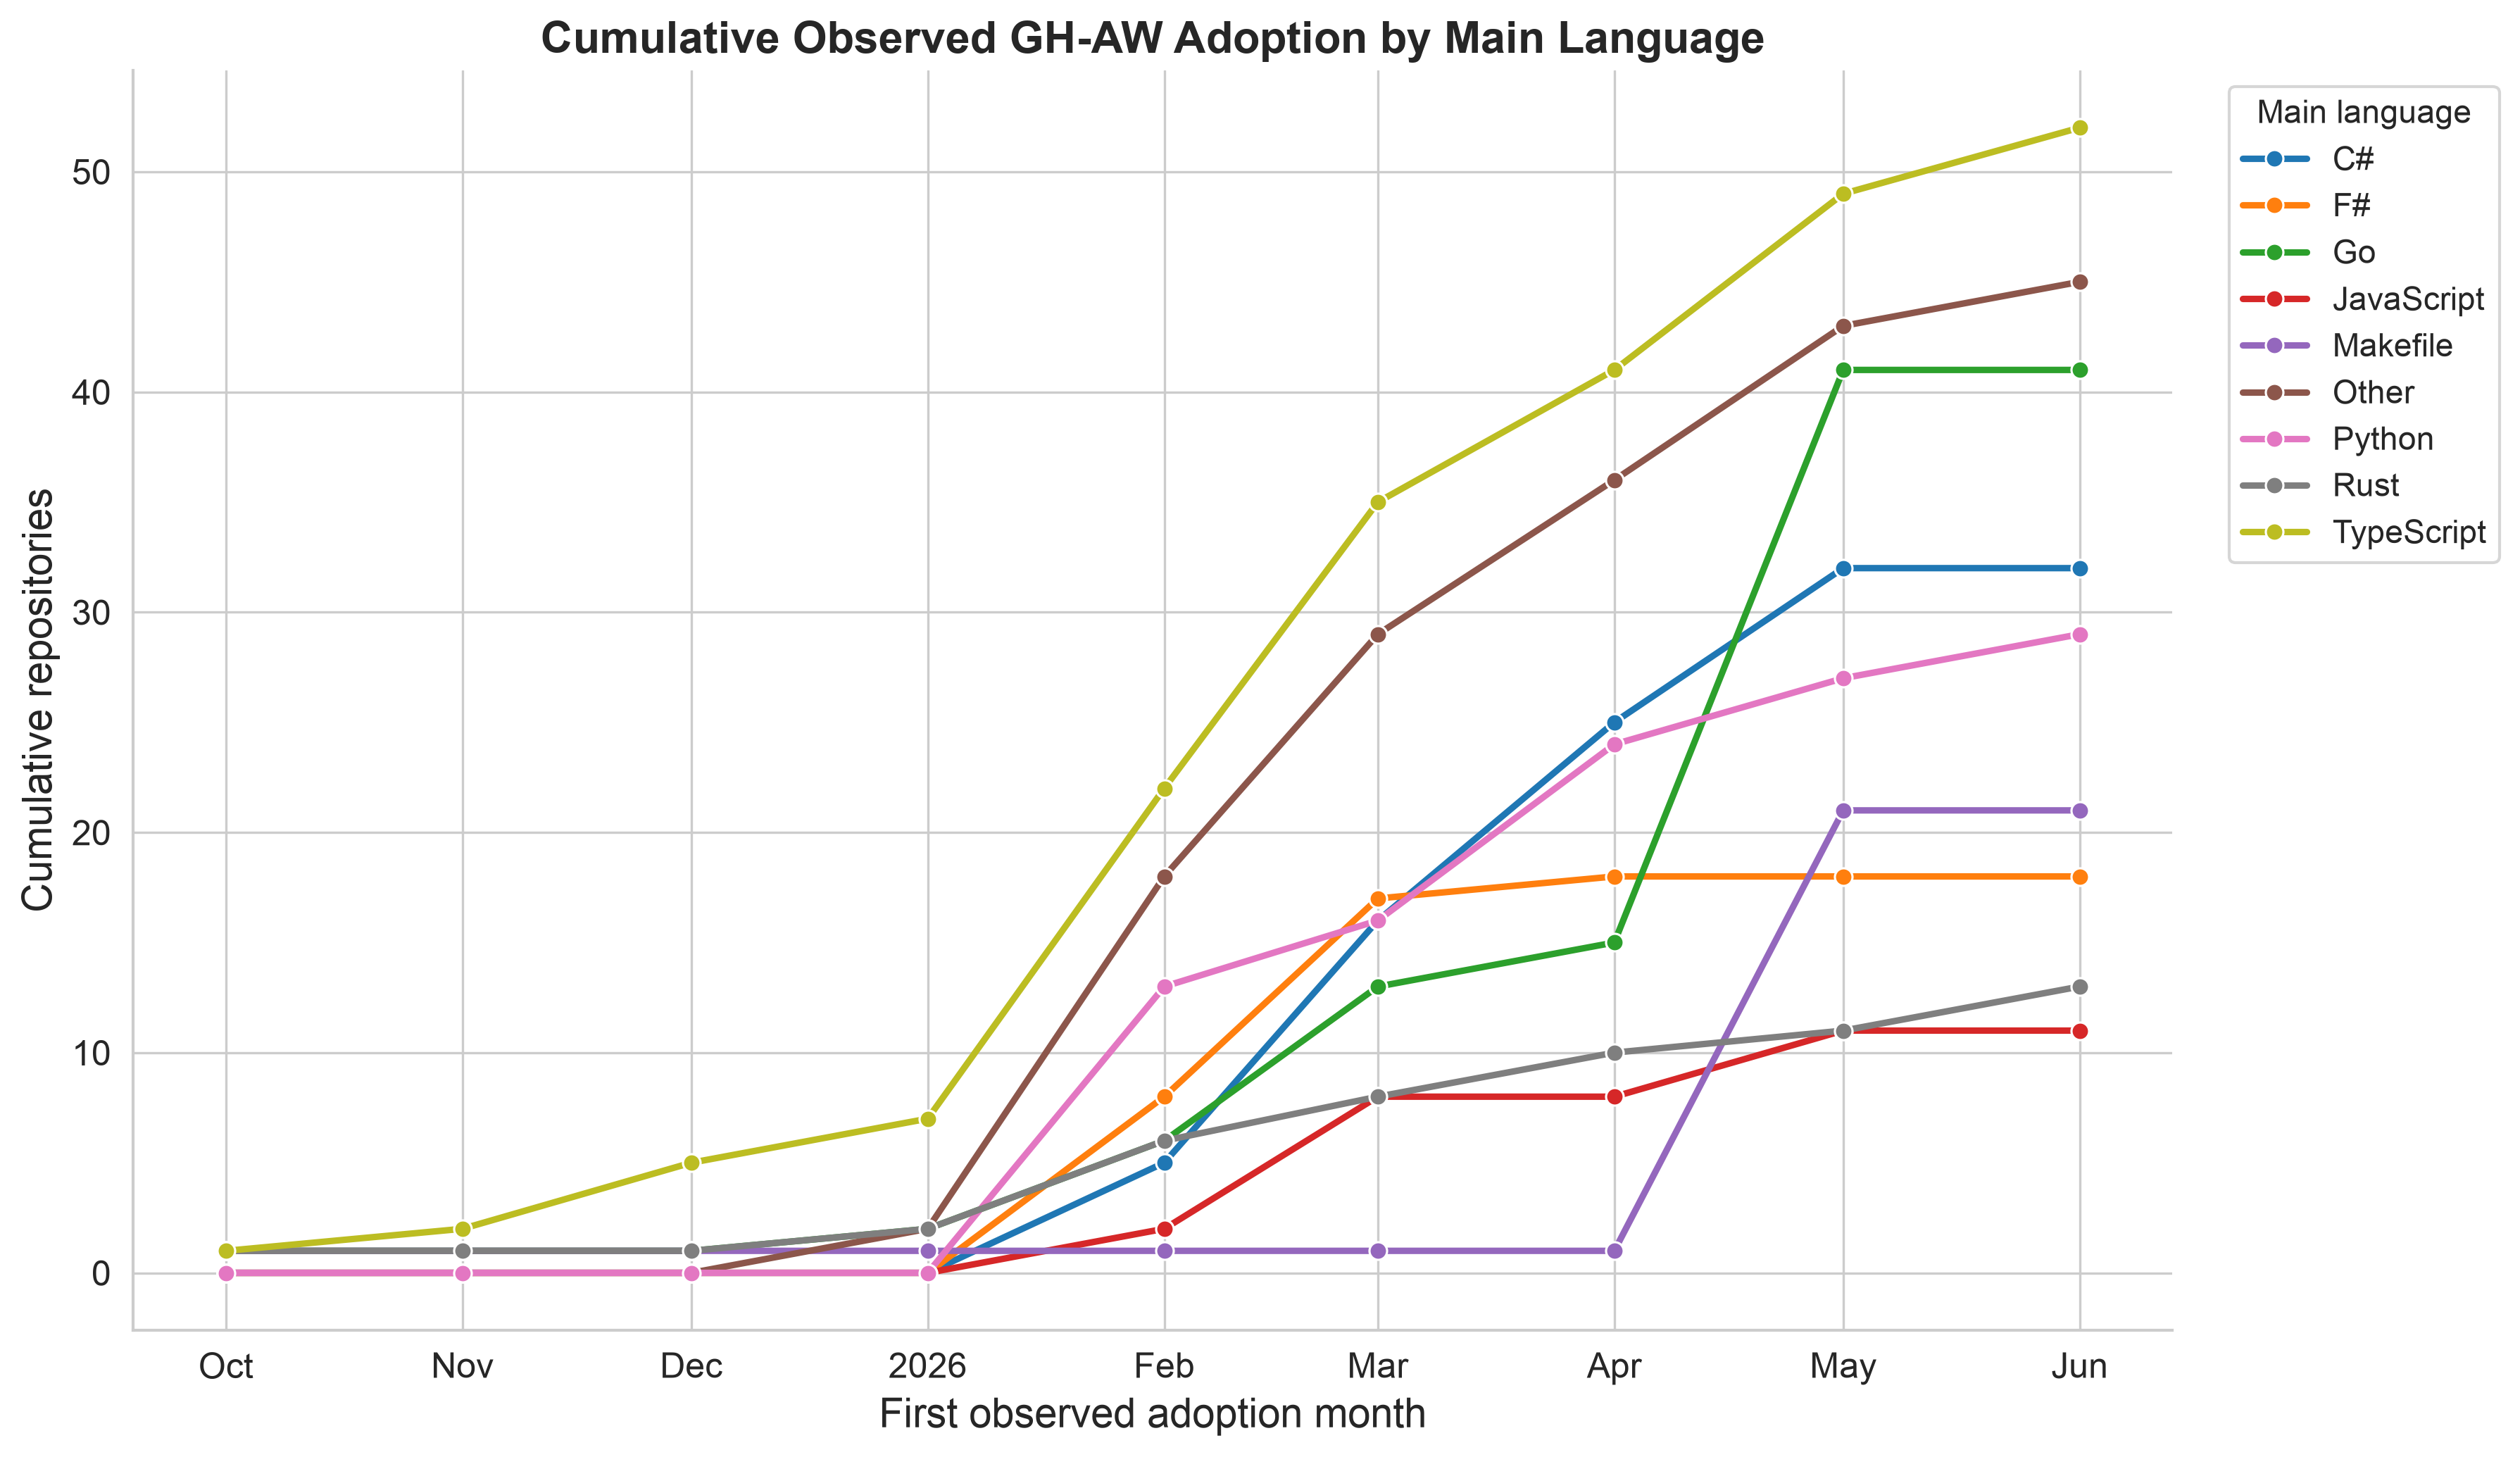

In [5]:
plot_language_cumulative(adoption_df, top_n=8)
